# **Customer Churn Prediction Platform for Retail Business Using Machine Learning and MLOps - EDA**

---

## **Import Library**

---

In [1]:
# Import Libraries
import sweetviz as sv
import pandas as pd

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

---

## **Data Loading**

---

In [2]:
# Load the dataset
df = pd.read_csv("../data/interim/cleaned_raw.csv")
df.head()

,customer_id,age_group,gender,region,customer_segment,preferred_channel,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_risk,churn_flag
0,C000001,18-24,Other,North,Loyal,Online,5,381.27,2108.80,189,27,0.38,0.13,0.42,33,35.5,Medium,1
1,C000002,25-34,Other,South,New,Mobile App,12,376.65,3843.06,277,68,0.51,0.06,0.07,68,49.5,Medium,1
2,C000003,55+,Other,North,VIP,Online,5,37.73,224.65,271,23,0.64,0.22,0.46,73,38.0,High,1
3,C000004,18-24,Male,North,Returning,Mobile App,12,191.19,1960.79,89,93,0.66,0.31,0.13,93,59.0,Low,0
4,C000005,55+,Other,North,Returning,Mobile App,2,279.64,594.79,264,4,0.73,0.27,0.58,11,34.5,High,1


**Insight:**

Data succesfully loading

---

## **Data Initiate**

---

### **Descriptive Analysis**

---

In [3]:
# Perform EDA using Sweetviz
data_report = sv.analyze(df)

                                             |          | [  0%]   00:00 -> (? left)

In [4]:
# Show the report
data_report.show_html("sweetviz_report.html")

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


**Insight:**

**Customer Churn Analysis — Key Insights from EDA**

**1. Dataset Overview**

This dataset contains customer-level retail data that can be used to analyze and predict customer churn.

Customer churn means that a customer stops buying, stops interacting, or is likely to leave the business.

Each row represents one customer, and each column describes customer profile, shopping behavior, digital activity, loyalty, engagement, or churn status.

The dataset includes several groups of features:

| Feature Group | Columns |
|---|---|
| Customer identity | `customer_id` |
| Customer profile | `age_group`, `gender`, `region`, `customer_segment`, `preferred_channel` |
| Purchase behavior | `purchase_frequency`, `avg_order_value`, `total_spent`, `recency_days` |
| Digital activity | `website_visits`, `email_open_rate`, `cart_abandonment_rate` |
| Loyalty and engagement | `loyalty_score`, `engagement_score` |
| Churn-related variables | `churn_risk`, `churn_flag` |

Overall, this dataset is suitable for churn analysis because it combines customer demographic information, transactional behavior, digital activity, and churn labels.

The main business objective is to understand which customers are likely to churn and what factors may influence churn behavior.

---

**2. Data Quality Insight**

The dataset appears to have good data quality.

There are no major signs of missing values or duplicate records in the Sweetviz report. This means the dataset can be used directly for exploratory data analysis.

However, even though the dataset looks clean, several preparation steps are still needed before building a machine learning model.

Important preparation steps include:

- `customer_id` should be removed from model features because it is only an identifier.
- Categorical variables should be encoded before modeling.
- Numerical variables should be checked for outliers.
- `churn_risk` should be reviewed carefully because it may cause data leakage if used to predict `churn_flag`.

Good data quality makes the analysis more reliable, but correct feature selection is still important.

---

**3. Understanding Customer Churn**

The main churn target variable is likely `churn_flag`.

Usually:

- `0` means the customer did not churn.
- `1` means the customer churned.

The purpose of churn prediction is to identify customers who are likely to leave so the business can take action before losing them.

The analysis suggests that churn is more strongly related to customer behavior than to basic customer profile information.

This means that variables such as customer activity, recency, engagement, and cart abandonment are more useful for churn analysis than variables such as gender, region, or age group.

In simple terms:

> Churn is more about what customers do than who customers are.

---

**4. Recency Is the Strongest Churn Signal**

One of the most important features in the dataset is `recency_days`.

`recency_days` represents how many days have passed since the customer last purchased or interacted with the business.

For example:

- A low `recency_days` value means the customer was recently active.
- A high `recency_days` value means the customer has been inactive for a long time.

This variable is very important because customer inactivity is usually one of the strongest signs of churn.

Business interpretation:

> The longer a customer stays inactive, the higher the probability that the customer will churn.

Customers with high `recency_days` should be prioritized for retention campaigns, win-back offers, reminders, or personalized communication.

---

**5. Cart Abandonment Indicates Purchase Friction**

`cart_abandonment_rate` is another important churn-related feature.

This variable shows how often customers add products to their cart but do not complete the purchase.

A high cart abandonment rate means the customer shows interest but does not finish the transaction.

Possible reasons include:

- The product price is too high.
- Shipping cost is too expensive.
- The checkout process is difficult.
- The customer is comparing prices with competitors.
- The customer is not fully convinced to purchase.
- The customer may have poor purchase experience.

Customers with high cart abandonment may be at risk because they show buying intention but do not complete the purchase.

Business interpretation:

> High cart abandonment can be an early warning sign that a customer may churn.

The business can reduce this risk by sending cart recovery emails, offering limited-time discounts, improving checkout experience, or giving personalized recommendations.

---

**6. Engagement and Loyalty Matter**

`engagement_score` and `loyalty_score` are important for understanding the relationship between the customer and the business.

A customer with a high engagement score is usually more active and more responsive to business communication.

A customer with a high loyalty score is usually more attached to the brand and more likely to continue buying.

On the other hand, customers with low engagement and low loyalty may be more likely to churn.

Business interpretation:

> Customers with low engagement and low loyalty should be monitored closely because they may need personalized retention strategies.

Examples of actions that can be used:

- Personalized email campaigns
- Loyalty points
- Exclusive rewards
- Special offers
- Product recommendations
- Re-engagement campaigns

---

**7. Purchase Behavior Insight**

Purchase behavior features such as `purchase_frequency`, `avg_order_value`, and `total_spent` help explain how valuable and active each customer is.

**`purchase_frequency`**

This shows how often a customer makes purchases.

Customers with higher purchase frequency are generally more active and more valuable.

**`avg_order_value`**

This shows the average amount a customer spends per order.

This variable is useful for understanding customer spending habits, but it may not be the strongest direct churn indicator.

**`total_spent`**

This shows the total amount spent by a customer.

Customers with high `total_spent` are important because they contribute more revenue to the business.

If a high-value customer has a high churn risk, the business should prioritize that customer because losing them may have a large financial impact.

Business interpretation:

> High-value customers with signs of churn should be prioritized in retention campaigns.

---

**8. Digital Activity Insight**

Digital activity features such as `website_visits`, `email_open_rate`, and `cart_abandonment_rate` help explain how customers interact with the business online.

**`website_visits`**

Customers with more website visits are usually more active and more interested in the business.

Website activity can be useful for understanding customer interest and purchase intention.

**`email_open_rate`**

This shows how often customers open marketing emails.

A higher email open rate usually means the customer is more responsive to communication.

**`cart_abandonment_rate`**

This is especially important because it shows customers who are interested but do not complete the purchase.

Business interpretation:

> Digital behavior can help identify customers who are active, interested, disengaged, or at risk of churn.

---

**9. Customer Profile Variables Are Less Dominant**

Customer profile variables include:

- `age_group`
- `gender`
- `region`
- `customer_segment`
- `preferred_channel`

These variables are useful for customer segmentation, marketing personalization, and business reporting.

However, they do not appear to be the strongest churn drivers.

This suggests that churn is not mainly explained by demographic differences.

Instead, churn is more related to customer behavior and activity patterns.

Business interpretation:

> It is better to focus churn prevention strategies on customer behavior rather than only customer demographics.

For example, rather than targeting customers only because they belong to a specific age group or region, the business should focus more on customers who have been inactive, have low engagement, or frequently abandon their cart.

---

**10. Churn Risk and Data Leakage Concern**

The feature `churn_risk` is highly related to `churn_flag`.

This is useful for business interpretation, but it can be risky for machine learning.

If `churn_risk` was created using information from `churn_flag`, then using it as a predictor can cause data leakage.

Data leakage happens when the model receives information that is too close to the answer.

In simple terms:

> The model may look very accurate, but it is actually learning from information that would not be available in a real prediction scenario.

For this reason, `churn_risk` should be handled carefully before building the model.

Recommended approach:

- Use `churn_flag` as the target variable.
- Remove `customer_id` from the feature set.
- Check how `churn_risk` was created.
- If `churn_risk` was derived from churn information, remove it from model features.

---

**11. Most Important Churn Drivers**

Based on the EDA, the most important churn-related features are likely:

| Feature | Why It Matters |
|---|---|
| `recency_days` | Shows how long the customer has been inactive |
| `cart_abandonment_rate` | Shows purchase hesitation or friction |
| `loyalty_score` | Shows customer loyalty level |
| `engagement_score` | Shows customer interaction level |
| `purchase_frequency` | Shows how often the customer buys |
| `website_visits` | Shows customer digital activity |
| `total_spent` | Shows customer value |

The strongest warning sign is customer inactivity.

Customers who have not interacted or purchased for a long time are more likely to churn.

---

**12. Business Recommendations**

Based on the EDA, the business should focus on customers who show early warning signs of churn.

**1. Target inactive customers**

Customers with high `recency_days` should receive win-back campaigns, reminders, or personalized offers.

These customers are important because inactivity is one of the strongest churn signals.

**2. Reduce cart abandonment**

Customers with high `cart_abandonment_rate` should receive cart recovery emails, limited-time discounts, or checkout support.

The business should also review the checkout process to reduce friction.

**3. Improve customer engagement**

Customers with low `engagement_score` should receive more relevant communication through their preferred channel.

Personalized recommendations, targeted emails, and special campaigns can help increase engagement.

**4. Strengthen customer loyalty**

Customers with low `loyalty_score` can be targeted with loyalty rewards, membership benefits, exclusive offers, or points-based incentives.

**5. Prioritize high-value customers**

Customers with high `total_spent` but increasing churn risk should be prioritized because losing them may have a larger business impact.

---

**13. Modeling Recommendations**

For churn prediction, the recommended target variable is:

- `churn_flag`

Features that should likely be removed or handled carefully:

| Feature | Recommendation | Reason |
|---|---|---|
| `customer_id` | Remove | It is only an identifier |
| `churn_risk` | Review carefully | It may cause data leakage |

Potential useful predictors include:

- `recency_days`
- `cart_abandonment_rate`
- `loyalty_score`
- `engagement_score`
- `purchase_frequency`
- `website_visits`
- `total_spent`
- `email_open_rate`
- `avg_order_value`
- `customer_segment`
- `preferred_channel`

Recommended baseline models:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM

Recommended evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

For churn prediction, recall is especially important because the business usually wants to identify as many churn customers as possible.

A high recall means the model is better at finding customers who are likely to churn.

---

**14. Final Insight**

The main insight from this dataset is that customer churn is more strongly influenced by behavioral signals than by demographic profile.

The most important warning sign is customer inactivity.

Customers who have not purchased or interacted for a long time are more likely to churn.

Therefore, the business should focus on early retention actions for customers with:

- high `recency_days`,
- high `cart_abandonment_rate`,
- low `engagement_score`,
- low `loyalty_score`,
- declining purchase activity.

By identifying these customers early, the business can design better retention campaigns, reduce customer loss, and improve customer lifetime value.

Final conclusion:

> Customer churn in this dataset is mainly driven by customer inactivity, weak engagement, low loyalty, and purchase friction. The best retention strategy is to detect these signals early and act before the customer leaves.

---

### **Churn Analysis**

---

In [5]:
# Define target and numerical columns
NUMERICAL_COLUMNS = [
    "purchase_frequency",
    "avg_order_value",
    "total_spent",
    "recency_days",
    "website_visits",
    "discount_usage_rate",
    "email_open_rate",
    "cart_abandonment_rate",
    "loyalty_score",
    "engagement_score",
]

#### **Churn by Customer Segment**

---

In [6]:
# Churn rate by customer segment
churn_by_segment = (
    df.groupby("customer_segment")["churn_flag"]
    .agg(["count", "mean"])
    .rename(columns={"count": "customer_count", "mean": "churn_rate"})
    .sort_values("churn_rate", ascending=False)
)

churn_by_segment

,customer_count,churn_rate
customer_segment,,
VIP,24906,0.466715
New,25113,0.463186
Returning,25106,0.459810
Loyal,24875,0.459256


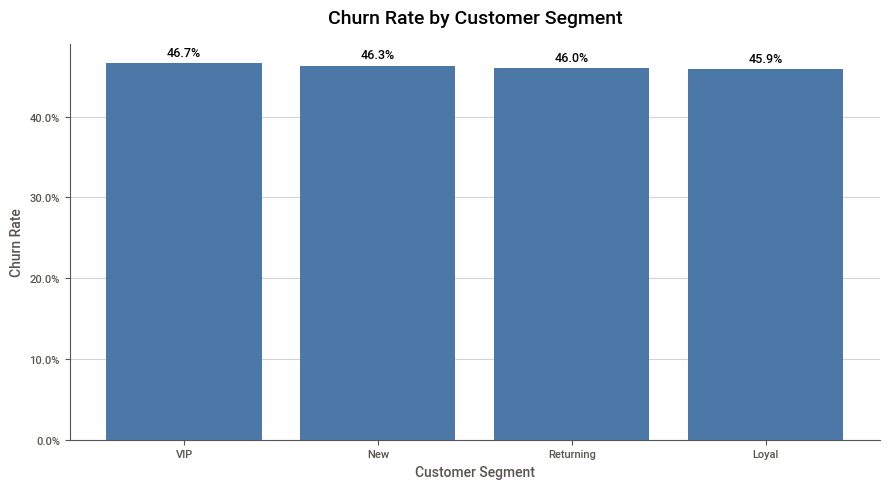

In [7]:
# Visualize churn rate by customer segment
plot_data = churn_by_segment.sort_values("churn_rate", ascending=False).copy()
plot_data["churn_rate_pct"] = plot_data["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    plot_data.index,
    plot_data["churn_rate_pct"],
    color="#4C78A8",
    edgecolor="none"
)

ax.set_title("Churn Rate by Customer Segment", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Customer Segment")
ax.set_ylabel("Churn Rate")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
# plt.savefig(FIGURES_PATH / "churn_by_segment.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**

The churn rate is very similar across all customer segments.

VIP customers have the highest churn rate at around 46.7%, while Loyal customers have the lowest churn rate at around 45.9%. However, the difference between the highest and lowest churn rate is only about 0.8 percentage points.

This indicates that customer segment alone is not a strong differentiator of churn behavior.

From a business perspective, this means the company should not rely only on customer segment to identify churn risk. Customers from all segments, including VIP and Loyal customers, still show a high probability of churn.

The overall churn rate is also high, at around 46%, which suggests that customer retention is a serious business issue.

To better understand churn, the business should combine customer segment with behavioral variables such as recency, purchase frequency, cart abandonment rate, engagement score, loyalty score, website visits, and total spending.

VIP customers should still be prioritized in retention campaigns because losing VIP customers may have a larger revenue impact. However, retention strategies should also be applied across all segments because churn risk is consistently high across the customer base.

Overall, customer segment is useful for business grouping, but it is not enough to explain or predict churn by itself.

---

#### **Churn by Age Group**

---

In [8]:
# Churn rate by region
churn_by_age = (
    df.groupby("age_group")["churn_flag"]
    .agg(["count", "mean"])
    .rename(columns={"count": "customer_count", "mean": "churn_rate"})
    .sort_values("churn_rate", ascending=False)
)

churn_by_age

,customer_count,churn_rate
age_group,,
55+,19882,0.465094
35-44,20109,0.463673
18-24,19987,0.462401
45-54,20093,0.461106
25-34,19929,0.458929


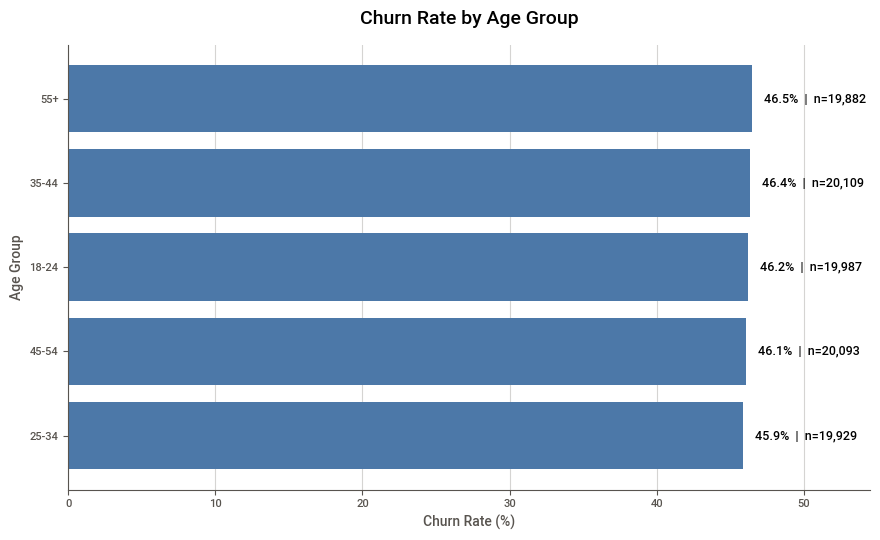

In [10]:
# Visualize churn rate by age group
plot_data = churn_by_age.copy()
plot_data["churn_rate"] = plot_data["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    plot_data.index.astype(str),
    plot_data["churn_rate"],
    color="#4C78A8",
    edgecolor="none"
)

ax.invert_yaxis()

ax.set_title("Churn Rate by Age Group", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Churn Rate (%)")
ax.set_ylabel("Age Group")

ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, count in zip(bars, plot_data["customer_count"]):
    value = bar.get_width()
    ax.text(
        value + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%  |  n={count:,}",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, plot_data["churn_rate"].max() + 8)

plt.tight_layout()
# plt.savefig(FIGURES_PATH / "churn_by_age.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**

The churn rate is very similar across all age groups.

The 55+ age group has the highest churn rate at around 46.5%, while the 25-34 age group has the lowest churn rate at around 45.9%. However, the difference between the highest and lowest churn rate is only about 0.6 percentage points.

This indicates that age group alone is not a strong differentiator of churn behavior.

From a business perspective, this means the company should not rely only on age group to identify customers who are likely to churn. Customers from all age groups show a similar probability of churn.

The consistently high churn rate across all age groups suggests that churn is a general customer retention issue, not a problem limited to one specific age segment.

Therefore, the business should focus more on behavioral variables such as recency, purchase frequency, cart abandonment rate, engagement score, loyalty score, website visits, and total spending.

Age group can still be useful for personalizing marketing messages, but it should not be treated as the main driver of churn.

Overall, age group is useful for segmentation, but it is not enough to explain or predict churn by itself.

---

#### **Churn by Gender**

---

In [ ]:
# Churn rate by region
churn_by_gender = (
    df.groupby("gender")["churn_flag"]
    .agg(["count", "mean"])
    .rename(columns={"count": "customer_count", "mean": "churn_rate"})
    .sort_values("churn_rate", ascending=False)
)

churn_by_gender

,customer_count,churn_rate
gender,,
Male,33434,0.463271
Female,33367,0.462703
Other,33199,0.460737


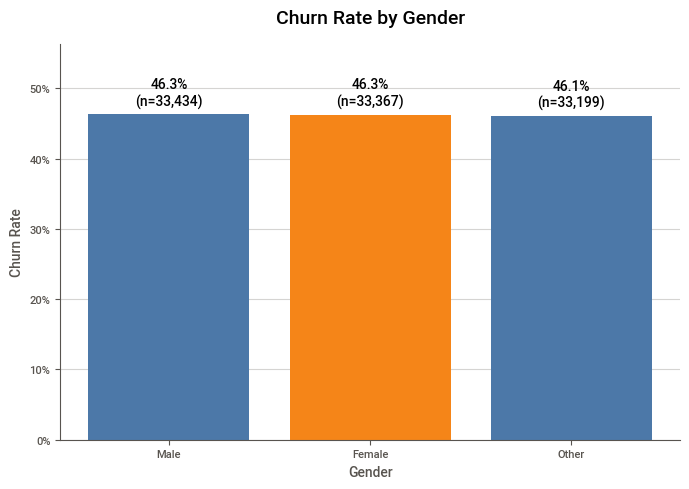

In [ ]:
# Visualize churn rate by gender
plot_data = churn_by_gender.copy()
plot_data["churn_rate_pct"] = plot_data["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    plot_data.index.astype(str),
    plot_data["churn_rate_pct"],
    color=["#4C78A8", "#F58518"],
    edgecolor="none"
)

ax.set_title("Churn Rate by Gender", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Gender")
ax.set_ylabel("Churn Rate")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}%\n(n={count:,})"
        for rate, count in zip(plot_data["churn_rate_pct"], plot_data["customer_count"])
    ],
    padding=4,
    fontsize=10
)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylim(0, plot_data["churn_rate_pct"].max() + 10)

plt.tight_layout()
# plt.savefig(FIGURES_PATH / "churn_by_gender.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**

The churn rate is almost identical across all gender groups.

Male customers have the highest churn rate at around 46.3%, followed very closely by Female customers at around 46.3%, and Other customers at around 46.1%. The difference between the highest and lowest churn rate is only about 0.2 percentage points.

This indicates that gender alone is not a strong differentiator of churn behavior.

From a business perspective, the company should not rely on gender to identify customers who are likely to churn. Customers across all gender groups show almost the same churn probability.

The consistently high churn rate across gender groups suggests that churn is a general retention problem, not an issue concentrated in one gender category.

Therefore, the business should focus more on behavioral variables such as recency, purchase frequency, cart abandonment rate, engagement score, loyalty score, website visits, and total spending.

Gender may still be useful for segmentation or personalization, but it should not be treated as a primary driver of churn.

Overall, gender is not enough to explain or predict churn by itself.

---

#### **Churn by Region**

---

In [ ]:
# Churn rate by region
churn_by_region = (
    df.groupby("region")["churn_flag"]
    .agg(["count", "mean"])
    .rename(columns={"count": "customer_count", "mean": "churn_rate"})
    .sort_values("churn_rate", ascending=False)
)

churn_by_region

,customer_count,churn_rate
region,,
West,20039,0.464993
Central,20012,0.464521
East,20240,0.463636
North,20035,0.463289
South,19674,0.454610


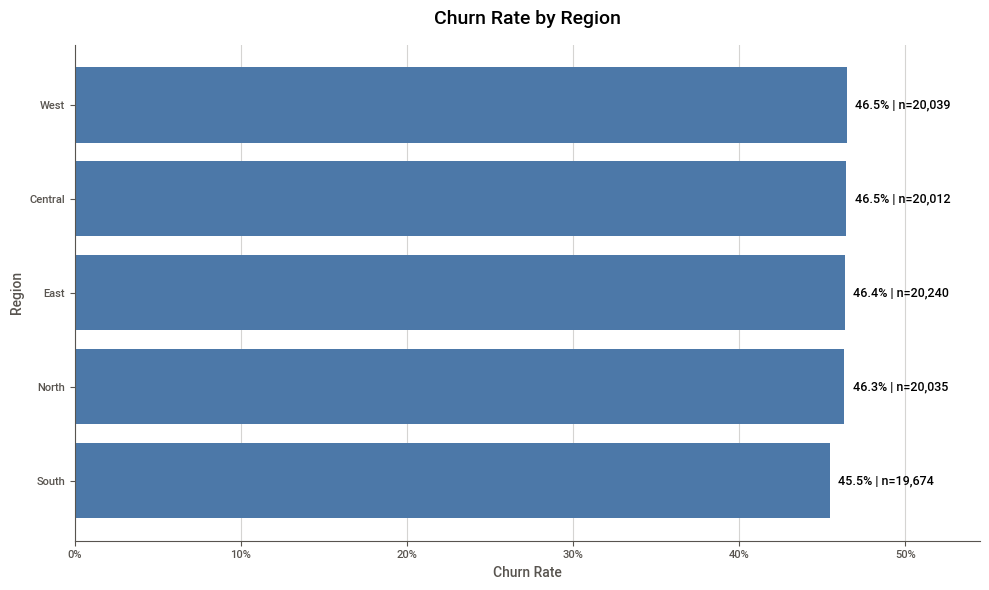

In [ ]:
# Visualize churn rate by region
plot_data = churn_by_region.copy()
plot_data["churn_rate_pct"] = plot_data["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_data.index.astype(str),
    plot_data["churn_rate_pct"],
    color="#4C78A8",
    edgecolor="none"
)

ax.invert_yaxis()  # highest churn on top

ax.set_title("Churn Rate by Region", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Churn Rate")
ax.set_ylabel("Region")

ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, rate, count in zip(bars, plot_data["churn_rate_pct"], plot_data["customer_count"]):
    ax.text(
        rate + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}% | n={count:,}",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, plot_data["churn_rate_pct"].max() + 8)

plt.tight_layout()
# plt.savefig(FIGURES_PATH / "churn_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**

The churn rate is very similar across all regions.

The West region has the highest churn rate at around 46.5%, followed closely by Central, East, and North. The South region has the lowest churn rate at around 45.5%.

However, the difference between the highest and lowest churn rate is only about 1.0 percentage point. This indicates that region alone is not a strong differentiator of churn behavior.

From a business perspective, the company should not rely only on region to identify customers who are likely to churn. Customers across all regions show a consistently high churn probability.

The slightly lower churn rate in the South region may be worth investigating, but the difference is too small to conclude that region is a major churn driver.

Overall, churn appears to be a general customer retention issue across all regions. The business should focus more on behavioral variables such as recency, purchase frequency, cart abandonment rate, engagement score, loyalty score, website visits, and total spending.

Region can still be useful for local campaign personalization, but it should not be treated as the main driver of churn.

---

#### **Churn by Preferred Channel**

---

In [ ]:
# Churn rate by preferred channel
churn_by_channel = (
    df.groupby("preferred_channel")["churn_flag"]
    .agg(["count", "mean"])
    .rename(columns={"count": "customer_count", "mean": "churn_rate"})
    .sort_values("churn_rate", ascending=False)
)

churn_by_channel

,customer_count,churn_rate
preferred_channel,,
Online,33430,0.466647
In-Store,33303,0.462571
Mobile App,33267,0.457480


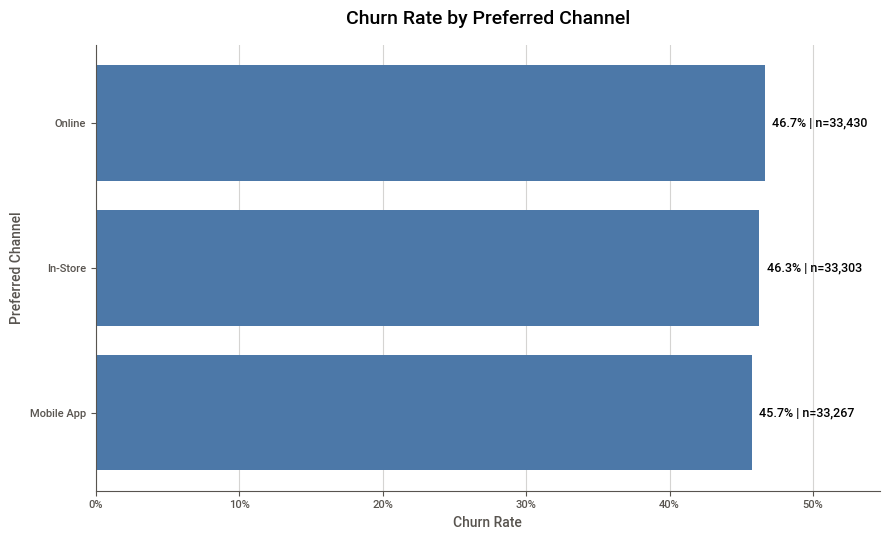

In [ ]:
# Visualize churn rate by preferred channel
plot_data = churn_by_channel.copy()
plot_data["churn_rate_pct"] = plot_data["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    plot_data.index.astype(str),
    plot_data["churn_rate_pct"],
    color="#4C78A8",
    edgecolor="none"
)

ax.invert_yaxis()

ax.set_title("Churn Rate by Preferred Channel", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Churn Rate")
ax.set_ylabel("Preferred Channel")

ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, rate, count in zip(bars, plot_data["churn_rate_pct"], plot_data["customer_count"]):
    ax.text(
        rate + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}% | n={count:,}",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, plot_data["churn_rate_pct"].max() + 8)

plt.tight_layout()
# plt.savefig(FIGURES_PATH / "churn_by_channel.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**

The churn rate is relatively similar across all preferred channels.

Online customers have the highest churn rate at around 46.7%, followed by In-Store customers at around 46.3%, and Mobile App customers at around 45.7%.

The difference between the highest and lowest churn rate is only about 1.0 percentage point. This indicates that preferred channel alone is not a strong differentiator of churn behavior.

However, the slightly higher churn rate among Online customers may suggest that online users are more likely to leave compared to mobile app users. This could be related to easier price comparison, weaker loyalty, checkout friction, delivery cost, or lower engagement.

The Mobile App channel has the lowest churn rate, which may indicate that app users are slightly more engaged or more connected to the brand. Mobile apps can support retention through push notifications, loyalty features, personalized offers, and easier repeat purchases.

From a business perspective, preferred channel should be used for campaign personalization, but it should not be treated as the main churn driver.

The business should focus more on behavioral variables such as recency, purchase frequency, cart abandonment rate, engagement score, loyalty score, website visits, and total spending.

Overall, churn is high across all channels, so retention efforts should be applied broadly, while messages and offers should be personalized based on each customer’s preferred channel.

---

#### **Churn by Purchase Frequency**

---

In [ ]:
# Analyze churn rate by purchase frequency (numerical variable)
df["purchase_frequency_bin"] = pd.qcut(
    df["purchase_frequency"],
    q=4,
    duplicates="drop"
)

churn_by_purchase_frequency = (
    df.groupby("purchase_frequency_bin", observed=False)["churn_flag"]
    .agg(["count", "mean"])
    .rename(columns={"count": "customer_count", "mean": "churn_rate"})
)

churn_by_purchase_frequency

,customer_count,churn_rate
purchase_frequency_bin,,
"(0.999, 2.0]",26925,0.481783
"(2.0, 8.0]",36945,0.471999
"(8.0, 12.0]",12092,0.461628
"(12.0, 60.0]",24038,0.425659


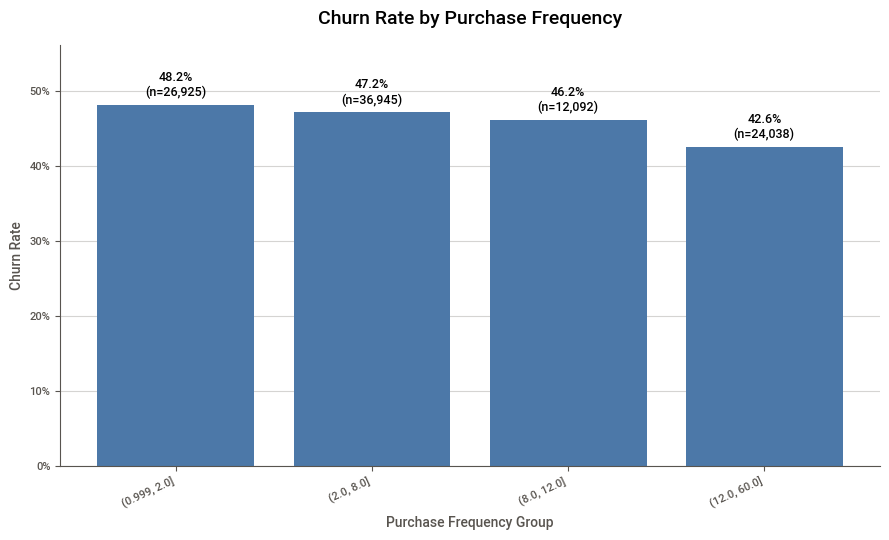

In [ ]:
# Visualize churn rate by purchase frequency
plot_data = churn_by_purchase_frequency.sort_index().copy()
plot_data["churn_rate_pct"] = plot_data["churn_rate"] * 100
plot_data.index = plot_data.index.astype(str)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    plot_data.index,
    plot_data["churn_rate_pct"],
    color="#4C78A8",
    edgecolor="none"
)

ax.set_title("Churn Rate by Purchase Frequency", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Purchase Frequency Group")
ax.set_ylabel("Churn Rate")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}%\n(n={count:,})"
        for rate, count in zip(plot_data["churn_rate_pct"], plot_data["customer_count"])
    ],
    padding=4,
    fontsize=9
)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylim(0, plot_data["churn_rate_pct"].max() + 8)

plt.xticks(rotation=0, ha="right")
plt.tight_layout()
# plt.savefig(FIGURES_PATH / "churn_by_purchase_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**

The churn rate decreases as purchase frequency increases.

Customers with only 1–2 purchases have the highest churn rate at around 48.2%, while customers with 13–60 purchases have the lowest churn rate at around 42.6%. The difference between these two groups is about 5.6 percentage points.

This indicates that purchase frequency is an important behavioral indicator of churn. Customers who purchase more often are less likely to churn, while customers with low purchase frequency are more likely to leave.

From a business perspective, this suggests that the company should focus on converting low-frequency customers into repeat customers. Customers who only purchased once or twice may not yet have developed strong loyalty or buying habits.

The business should target low-frequency customers with second-purchase incentives, personalized recommendations, follow-up campaigns, loyalty points, and limited-time offers.

Medium-frequency customers should also be nurtured through personalized promotions, cross-selling, and loyalty programs to increase their purchase habit.

High-frequency customers have the lowest churn rate, but their churn rate is still relatively high. Because these customers are valuable, the business should protect them with VIP rewards, exclusive offers, priority service, and personalized retention campaigns.

Overall, purchase frequency is more useful for explaining churn than demographic variables. The more frequently a customer purchases, the lower their churn risk tends to be.

---

#### **Churn by Recency**

---

In [ ]:
# Analyze churn rate by recency (numerical variable)
df["recency_bin"] = pd.qcut(
    df["recency_days"],
    q=4,
    duplicates="drop"
)

churn_by_recency = (
    df.groupby("recency_bin", observed=False)["churn_flag"]
    .agg(["count", "mean"])
    .rename(columns={"count": "customer_count", "mean": "churn_rate"})
)

churn_by_recency

,customer_count,churn_rate
recency_bin,,
"(0.999, 92.0]",25149,0.007038
"(92.0, 182.0]",24855,0.186763
"(182.0, 274.0]",25173,0.684027
"(274.0, 364.0]",24823,0.974338


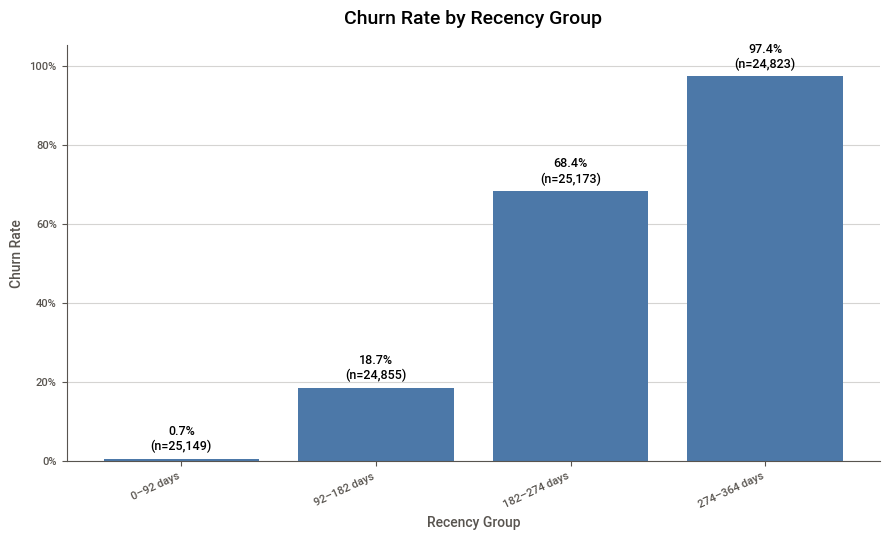

In [ ]:
# Visualize churn rate by recency group
plot_data = churn_by_recency.sort_index().copy()
plot_data["churn_rate_pct"] = plot_data["churn_rate"] * 100

plot_data.index = [
    f"{int(interval.left)}–{int(interval.right)} days"
    for interval in plot_data.index
]

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    plot_data.index,
    plot_data["churn_rate_pct"],
    color="#4C78A8",
    edgecolor="none"
)

ax.set_title("Churn Rate by Recency Group", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Recency Group")
ax.set_ylabel("Churn Rate")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}%\n(n={count:,})"
        for rate, count in zip(plot_data["churn_rate_pct"], plot_data["customer_count"])
    ],
    padding=4,
    fontsize=9
)

ax.set_ylim(0, plot_data["churn_rate_pct"].max() + 8)

plt.xticks(rotation=0, ha="right")
plt.tight_layout()
# plt.savefig(FIGURES_PATH / "churn_by_recency.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**

The churn rate increases sharply as customer inactivity increases.

Customers who were active within the last 0–92 days have a very low churn rate of around 0.7%. This indicates that recently active customers are very unlikely to churn.

However, churn increases significantly as recency becomes higher. Customers inactive for 92–182 days have a churn rate of around 18.7%, while customers inactive for 182–274 days have a much higher churn rate of around 68.4%.

The highest-risk group is customers inactive for 274–364 days, with a churn rate of around 97.4%. This means that customers who have not interacted for a long time are almost certain to churn.

This is one of the strongest churn patterns in the dataset. The difference between the lowest and highest recency group is about 96.7 percentage points, which shows that recency is a very powerful churn indicator.

From a business perspective, the company should not wait until customers become inactive for too long. Retention campaigns should start earlier, especially when customers enter the 92–182 day inactivity range.

Customers inactive for 182–274 days should be treated as high-risk customers and targeted with stronger win-back campaigns. Customers inactive for 274–364 days may require aggressive reactivation campaigns, but the business should prioritize high-value customers in this group because recovery may be difficult.

Overall, recency is a critical behavioral feature for churn prediction and retention strategy. The longer a customer has been inactive, the higher their churn risk becomes.

---

#### **Churn by Total Spent**

---

In [ ]:
# Analyze churn rate by total spent (numerical variable)
df["total_spent_bin"] = pd.qcut(
    df["total_spent"],
    q=4,
    duplicates="drop"
)

churn_by_total_spent = (
    df.groupby("total_spent_bin", observed=False)["churn_flag"]
    .agg(["count", "mean"])
    .rename(columns={"count": "customer_count", "mean": "churn_rate"})
)

churn_by_total_spent

,customer_count,churn_rate
total_spent_bin,,
"(17.869, 381.318]",25000,0.48300
"(381.318, 1089.18]",25000,0.47440
"(1089.18, 2952.172]",25000,0.45936
"(2952.172, 28444.24]",25000,0.43220


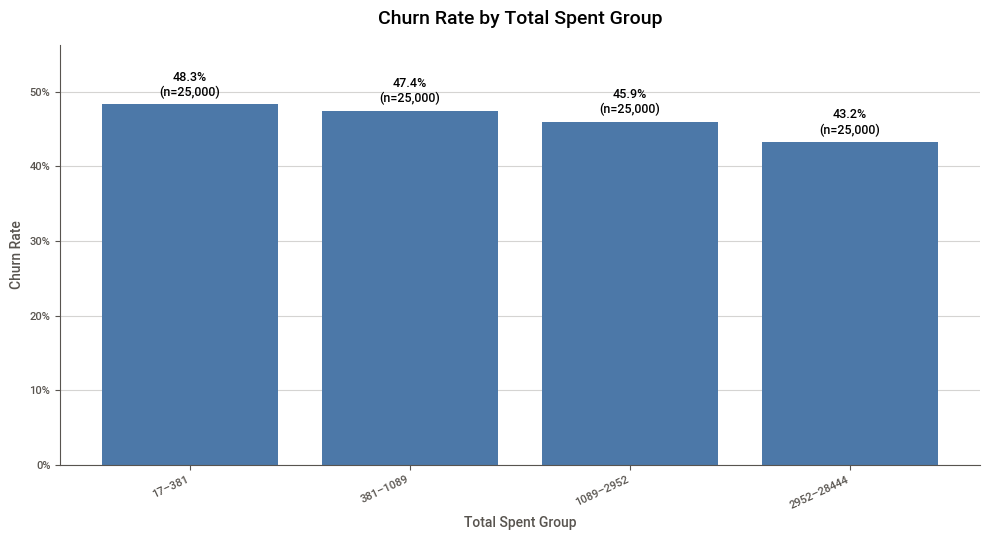

In [ ]:
# Visualize churn rate by total spent group
plot_data = churn_by_total_spent.sort_index().copy()
plot_data["churn_rate_pct"] = plot_data["churn_rate"] * 100

plot_data.index = [
    f"{int(interval.left)}–{int(interval.right)}"
    for interval in plot_data.index
]

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(
    plot_data.index,
    plot_data["churn_rate_pct"],
    color="#4C78A8",
    edgecolor="none"
)

ax.set_title("Churn Rate by Total Spent Group", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Total Spent Group")
ax.set_ylabel("Churn Rate")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}%\n(n={count:,})"
        for rate, count in zip(plot_data["churn_rate_pct"], plot_data["customer_count"])
    ],
    padding=4,
    fontsize=9
)

ax.set_ylim(0, plot_data["churn_rate_pct"].max() + 8)

plt.xticks(rotation=0, ha="right")
plt.tight_layout()
# plt.savefig(FIGURES_PATH / "churn_by_total_spent.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**

The churn rate decreases as total spending increases.

Customers in the lowest total spent group have the highest churn rate at around 48.3%, while customers in the highest total spent group have the lowest churn rate at around 43.2%. The difference between these two groups is about 5.1 percentage points.

This indicates that total spending is an important behavioral indicator of churn. Customers who have spent more are generally less likely to churn, while customers with lower total spending are more likely to leave.

From a business perspective, low-spending customers may not yet have built a strong relationship with the business. They may have made only a few purchases, may be less engaged, or may not have found enough value to continue buying.

However, high-spending customers should not be ignored. Although they have the lowest churn rate, their churn rate is still around 43.2%. Losing these customers can have a larger financial impact because they contribute more revenue.

The business should focus on converting low-spending customers into repeat buyers through second-purchase incentives, personalized recommendations, follow-up campaigns, and loyalty program introduction.

For high-spending customers, the business should focus on protection and retention through VIP rewards, exclusive offers, priority service, and personalized appreciation campaigns.

Overall, total spent is more useful for explaining churn than demographic variables. The higher the customer’s total spending, the lower their churn risk tends to be. However, total spent should be combined with other behavioral features such as recency, purchase frequency, engagement score, loyalty score, and cart abandonment rate for better churn analysis.

---

#### **Churn by Discount Usage**

---

In [ ]:
# Analyze churn rate by discount usage rate (numerical variable)
df["discount_usage_bin"] = pd.qcut(
    df["discount_usage_rate"],
    q=4,
    duplicates="drop"
)

churn_by_discount = (
    df.groupby("discount_usage_bin", observed=False)["churn_flag"]
    .agg(["count", "mean"])
    .rename(columns={"count": "customer_count", "mean": "churn_rate"})
)

churn_by_discount

,customer_count,churn_rate
discount_usage_bin,,
"(0.049, 0.24]",25851,0.459827
"(0.24, 0.43]",25372,0.463976
"(0.43, 0.61]",23809,0.462766
"(0.61, 0.8]",24968,0.462472


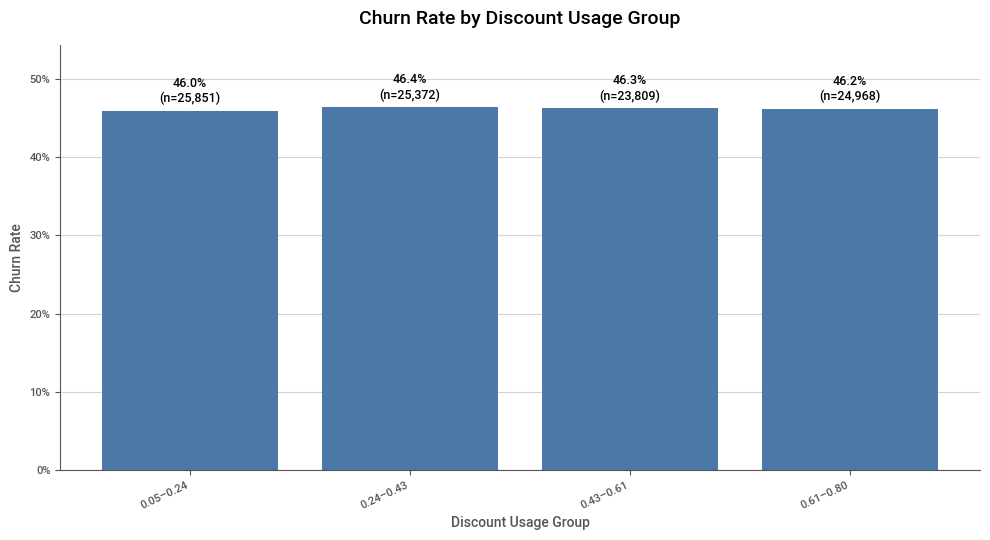

In [ ]:
# Visualize churn rate by discount usage group
plot_data = churn_by_discount.sort_index().copy()
plot_data["churn_rate_pct"] = plot_data["churn_rate"] * 100

plot_data.index = [
    f"{interval.left:.2f}–{interval.right:.2f}"
    for interval in plot_data.index
]

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(
    plot_data.index,
    plot_data["churn_rate_pct"],
    color="#4C78A8",
    edgecolor="none"
)

ax.set_title("Churn Rate by Discount Usage Group", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Discount Usage Group")
ax.set_ylabel("Churn Rate")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}%\n(n={count:,})"
        for rate, count in zip(plot_data["churn_rate_pct"], plot_data["customer_count"])
    ],
    padding=4,
    fontsize=9
)

ax.set_ylim(0, plot_data["churn_rate_pct"].max() + 8)

plt.xticks(rotation=0, ha="right")
plt.tight_layout()
# plt.savefig(FIGURES_PATH / "churn_by_discount_usage.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**

The churn rate is almost the same across all discount usage groups.

Customers with low discount usage have a churn rate of around 46.0%, while customers with higher discount usage groups have churn rates around 46.2% to 46.4%. The difference between the highest and lowest churn rate is only about 0.4 percentage points.

This indicates that discount usage alone is not a strong differentiator of churn behavior.

From a business perspective, this means customers who use more discounts are not necessarily less likely to churn. Discounts may help encourage short-term purchases, but they do not appear to strongly improve customer retention by themselves.

This is an important finding because businesses often assume that offering more discounts will reduce churn. However, the flat churn pattern suggests that churn may be driven more by behavioral factors such as recency, engagement, loyalty, purchase frequency, and cart abandonment rather than discount usage.

The business should avoid relying on broad discount campaigns as the main retention strategy. Instead, discounts should be targeted toward customers who show clear churn signals, such as high recency days, low engagement score, low loyalty score, high cart abandonment rate, or declining purchase frequency.

Overall, discount usage may be useful as a supporting retention tactic, but it should not be treated as a primary churn driver.

---

#### **Churn by Cart Abandonment**

---

In [ ]:
df["cart_abandonment_bin"] = pd.qcut(
    df["cart_abandonment_rate"],
    q=4,
    duplicates="drop"
)

churn_by_cart_abandonment = (
    df.groupby("cart_abandonment_bin", observed=False)["churn_flag"]
    .agg(["count", "mean"])
    .rename(columns={"count": "customer_count", "mean": "churn_rate"})
)

churn_by_cart_abandonment

,customer_count,churn_rate
cart_abandonment_bin,,
"(0.049, 0.25]",25416,0.313661
"(0.25, 0.45]",25118,0.416992
"(0.45, 0.65]",25019,0.514369
"(0.65, 0.85]",24447,0.609850


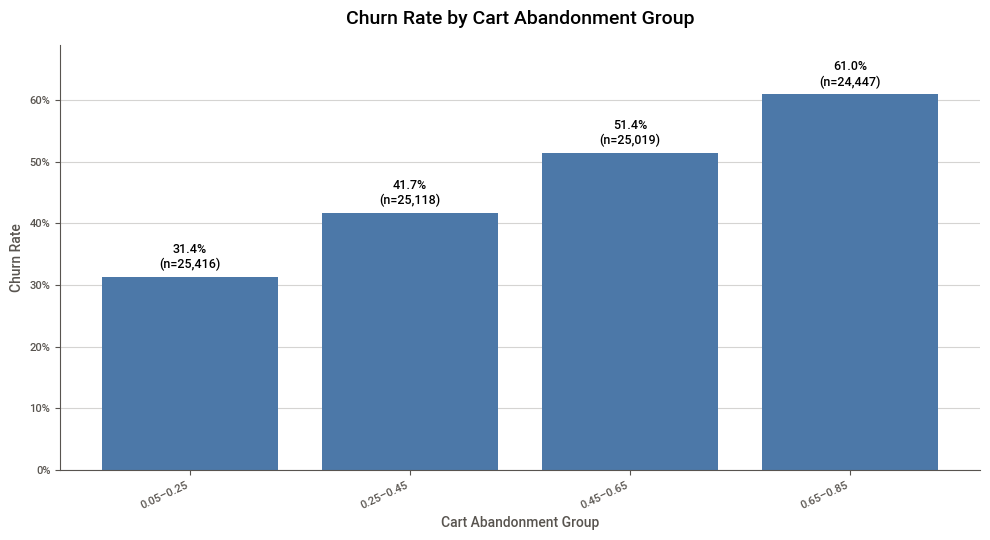

In [ ]:
# Visualize churn rate by cart abandonment group
plot_data = churn_by_cart_abandonment.sort_index().copy()
plot_data["churn_rate_pct"] = plot_data["churn_rate"] * 100

plot_data.index = [
    f"{interval.left:.2f}–{interval.right:.2f}"
    for interval in plot_data.index
]

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(
    plot_data.index,
    plot_data["churn_rate_pct"],
    color="#4C78A8",
    edgecolor="none"
)

ax.set_title("Churn Rate by Cart Abandonment Group", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Cart Abandonment Group")
ax.set_ylabel("Churn Rate")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}%\n(n={count:,})"
        for rate, count in zip(plot_data["churn_rate_pct"], plot_data["customer_count"])
    ],
    padding=4,
    fontsize=9
)

ax.set_ylim(0, plot_data["churn_rate_pct"].max() + 8)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
# plt.savefig(FIGURES_PATH / "churn_by_cart_abandonment.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**

The churn rate increases clearly as cart abandonment rate increases.

Customers with the lowest cart abandonment rate, between 0.05 and 0.25, have the lowest churn rate at around 31.4%. In contrast, customers with the highest cart abandonment rate, between 0.65 and 0.85, have the highest churn rate at around 61.0%.

The difference between the lowest and highest cart abandonment groups is about 29.6 percentage points. This is a strong signal that cart abandonment is an important behavioral indicator of churn.

From a business perspective, customers who frequently abandon their carts may still be interested in the products, but they are not completing the purchase. This may happen because of high prices, expensive shipping, checkout friction, limited payment options, weak product confidence, or comparison with competitors.

The business should treat high cart abandonment customers as a priority group for churn prevention. Recommended actions include abandoned-cart reminder emails, limited-time offers, free shipping, checkout improvements, product recommendations, and personalized recovery campaigns.

Customers in the medium-high abandonment group should also be monitored early because their churn rate is already above 50%. The company should intervene before these customers move into the highest-risk group.

Overall, cart abandonment rate is much more useful for explaining churn than demographic variables. A higher cart abandonment rate indicates higher purchase friction and higher churn risk.

---

#### **Churn by Engagement Score**

---

In [ ]:
# Analyze churn rate by engagement score (numerical variable)
df["engagement_score_bin"] = pd.qcut(
    df["engagement_score"],
    q=4,
    duplicates="drop"
)

churn_by_engagement = (
    df.groupby("engagement_score_bin", observed=False)["churn_flag"]
    .agg(["count", "mean"])
    .rename(columns={"count": "customer_count", "mean": "churn_rate"})
)

churn_by_engagement

,customer_count,churn_rate
engagement_score_bin,,
"(9.999, 39.0]",25044,0.561212
"(39.0, 51.0]",25224,0.486204
"(51.0, 63.0]",24794,0.439018
"(63.0, 92.0]",24938,0.361697


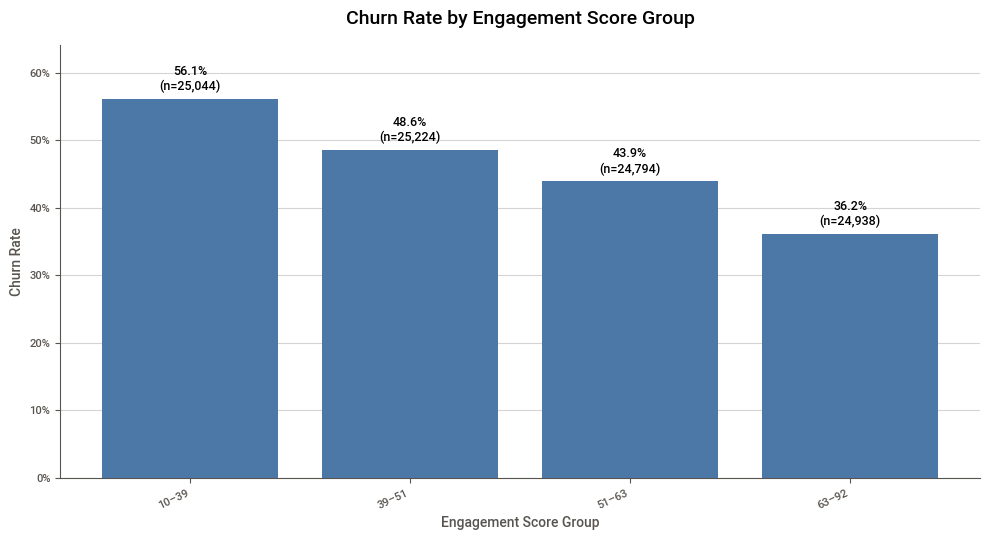

In [ ]:
# Visualize churn rate by engagement score group
plot_data = churn_by_engagement.sort_index().copy()
plot_data["churn_rate_pct"] = plot_data["churn_rate"] * 100

plot_data.index = [
    f"{interval.left:.0f}–{interval.right:.0f}"
    for interval in plot_data.index
]

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(
    plot_data.index,
    plot_data["churn_rate_pct"],
    color="#4C78A8",
    edgecolor="none"
)

ax.set_title("Churn Rate by Engagement Score Group", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Engagement Score Group")
ax.set_ylabel("Churn Rate")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}%\n(n={count:,})"
        for rate, count in zip(plot_data["churn_rate_pct"], plot_data["customer_count"])
    ],
    padding=4,
    fontsize=9
)

ax.set_ylim(0, plot_data["churn_rate_pct"].max() + 8)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
# plt.savefig(FIGURES_PATH / "churn_by_engagement_score.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**

The churn rate decreases as engagement score increases.

Customers in the lowest engagement score group, between 10 and 39, have the highest churn rate at around 56.1%. Customers in the highest engagement score group, between 63 and 92, have the lowest churn rate at around 36.2%.

The difference between the lowest and highest engagement groups is about 19.9 percentage points. This indicates that engagement score is an important behavioral indicator of churn.

From a business perspective, customers with low engagement are more likely to churn because they may no longer be actively connected to the business. They may open fewer emails, visit the website or app less often, respond less to promotions, or purchase less frequently.

Low engagement should be treated as an early warning signal. Customers usually become less active before they churn, so the business should monitor engagement score regularly.

The company should prioritize low-engagement customers with re-engagement campaigns, personalized recommendations, limited-time offers, loyalty incentives, and messages through the customer’s preferred channel.

Medium-engagement customers should also be nurtured to prevent them from moving into a higher-risk group. High-engagement customers should still be protected because their churn rate is lower but still meaningful.

Overall, engagement score is much more useful for explaining churn than demographic variables. Higher engagement is associated with lower churn risk, so improving customer engagement should be a key part of the retention strategy.

---

#### **Numerical Feature Comparison by Churn**

---

In [ ]:
# Visualize churn rate by engagement score group
num_summary_by_churn = (
    df.groupby("churn_flag")[NUMERICAL_COLUMNS]
    .mean()
    .T
)

num_summary_by_churn

churn_flag,0,1
purchase_frequency,12.466342,11.029595
avg_order_value,210.145141,209.192351
total_spent,2692.556727,2370.936140
recency_days,107.301993,270.504110
website_visits,61.745649,54.776804
discount_usage_rate,0.425870,0.426681
email_open_rate,0.473958,0.475171
cart_abandonment_rate,0.402234,0.507693
loyalty_score,58.834926,49.709588
engagement_score,53.586209,48.373875


**Insight:**

This comparison shows the average numerical feature values for non-churned customers (`churn_flag = 0`) and churned customers (`churn_flag = 1`).

The strongest difference appears in `recency_days`. Non-churned customers have an average recency of around 107 days, while churned customers have an average recency of around 270 days. This means churned customers have been inactive for much longer. From a business perspective, customer inactivity is one of the strongest churn warning signals.

Churned customers also have lower purchase frequency, lower total spending, and fewer website visits. This suggests that customers who buy less often, spend less overall, and interact less with the website are more likely to churn.

Cart abandonment is higher among churned customers. Non-churned customers have an average cart abandonment rate of around 0.40, while churned customers have an average of around 0.51. This indicates that churned customers may still show purchase interest, but they do not complete the transaction. This could be caused by price sensitivity, shipping cost, checkout friction, lack of trust, or better competitor offers.

Loyalty score and engagement score are also lower among churned customers. This means customers with weaker brand loyalty and lower engagement are more likely to leave. These features can be useful early warning indicators for retention campaigns.

On the other hand, average order value, discount usage rate, and email open rate are almost the same between churned and non-churned customers. This suggests that these features alone are not strong differentiators of churn.

Overall, the numerical comparison shows that churn is mainly driven by customer inactivity, lower purchase activity, lower total spending, higher cart abandonment, weaker loyalty, and lower engagement. The business should focus retention strategies on customers with high recency days, high cart abandonment, low loyalty score, low engagement score, and declining purchase behavior.

---

#### **Correlation heatmap**

---

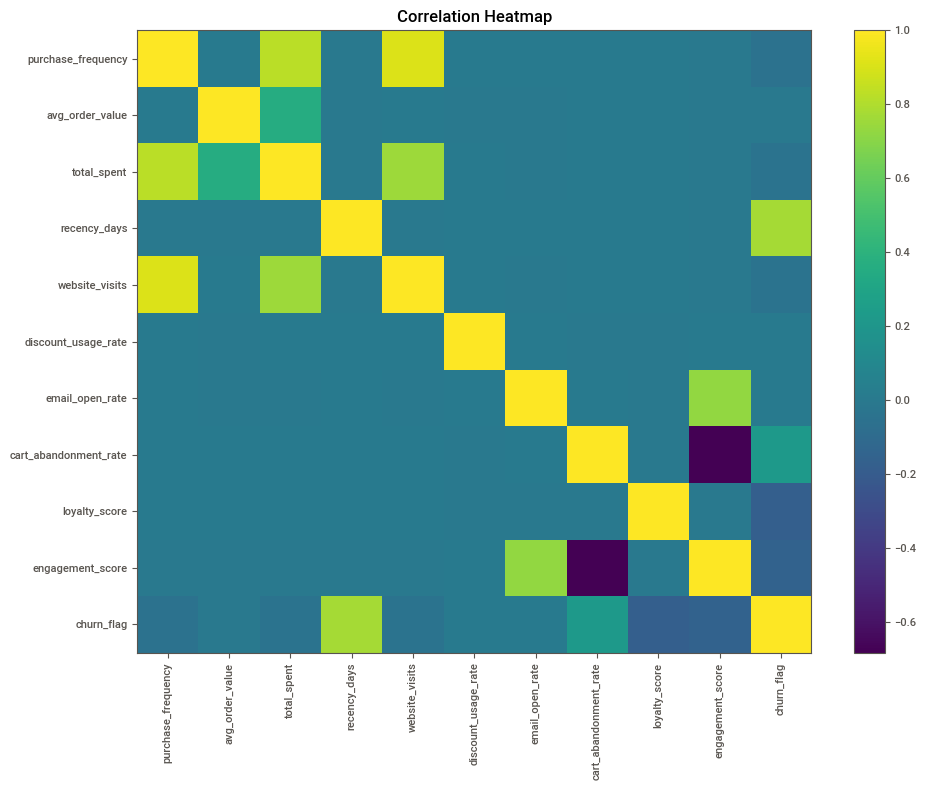

In [ ]:
# Correlation heatmap
corr = df[NUMERICAL_COLUMNS + ["churn_flag"]].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap")
plt.tight_layout()
# plt.savefig(FIGURES_PATH / "correlation_heatmap.png", dpi=300)
plt.show()

**Insight:**

The correlation heatmap shows that churn is mainly related to customer behavior.

The strongest relationship with churn is `recency_days`. This means customers who have been inactive for a longer time are much more likely to churn. From a business perspective, customer inactivity should be treated as the most important warning signal.

`cart_abandonment_rate` also has a positive relationship with churn. Customers who frequently abandon their carts are more likely to leave. This may indicate purchase friction, such as high prices, expensive shipping, difficult checkout process, limited payment options, or stronger competitor offers.

`engagement_score` and `loyalty_score` have negative relationships with churn. This means customers with higher engagement and stronger loyalty are less likely to churn. Low engagement and low loyalty should be monitored as early warning signs.

The heatmap also shows strong positive relationships among `purchase_frequency`, `website_visits`, and `total_spent`. Customers who visit more often tend to purchase more often and spend more overall. This suggests that active customers are usually more valuable and more engaged.

`email_open_rate` is strongly related to `engagement_score`, which means email interaction contributes to overall customer engagement. However, email open rate alone does not appear to be a strong direct churn driver.

`discount_usage_rate` has weak relationships with most variables, including churn. This suggests that discount usage alone does not strongly explain customer churn. Discounts may support retention, but they should be targeted to customers with clear churn signals rather than applied broadly.

Overall, the correlation heatmap confirms that churn is driven more by behavioral signals than by simple promotional or demographic factors. The business should prioritize customers with high `recency_days`, high `cart_abandonment_rate`, low `engagement_score`, low `loyalty_score`, and declining purchase activity.

---

#### **Revenue at Risk**

---

In [ ]:
# Calculate revenue at risk
revenue_at_risk = df.loc[df["churn_flag"] == 1, "total_spent"].sum()
total_revenue = df["total_spent"].sum()
revenue_at_risk_ratio = revenue_at_risk / total_revenue

print(f"Total revenue: {total_revenue:,.2f}")
print(f"Revenue at risk: {revenue_at_risk:,.2f}")
print(f"Revenue at risk ratio: {revenue_at_risk_ratio:.2%}")

Total revenue: 254,389,082.70
Revenue at risk: 109,594,152.14
Revenue at risk ratio: 43.08%


**Insight:**

The total revenue is approximately 254.39 million, while the revenue at risk is approximately 109.59 million. This means that around 43.08% of total revenue is potentially exposed to churn risk.

From a business perspective, this is a serious concern because churn does not only mean losing customers; it also means losing future revenue, repeat purchases, customer lifetime value, and potential long-term business value.

A revenue at risk ratio of 43.08% indicates that a large portion of the company’s revenue is connected to customers who may churn or are already showing churn risk signals. Therefore, churn prevention should be treated as a revenue protection strategy, not only as a customer retention activity.

The business should prioritize customers who have both high churn risk and high revenue contribution. These customers should receive personalized retention campaigns, VIP rewards, loyalty benefits, exclusive offers, or direct reactivation campaigns.

Instead of applying broad discounts to all customers, the company should focus retention budget on high-value customers at risk. This approach helps protect revenue more efficiently and reduces unnecessary promotional spending.

Overall, the company has a significant amount of revenue at risk, so reducing churn among high-value customers can have a strong positive financial impact.

---

#### **High-risk customer profile**

---

In [ ]:
# Analyze high-risk customer profile
high_risk_customers = df[df["churn_flag"] == 1].copy()

high_risk_profile = high_risk_customers[NUMERICAL_COLUMNS].mean().to_frame(
    "high_risk_customer_average"
)

overall_profile = df[NUMERICAL_COLUMNS].mean().to_frame(
    "overall_customer_average"
)

profile_comparison = high_risk_profile.join(overall_profile)
profile_comparison["difference"] = (
    profile_comparison["high_risk_customer_average"]
    - profile_comparison["overall_customer_average"]
)

profile_comparison.sort_values("difference", ascending=False)

,high_risk_customer_average,overall_customer_average,difference
recency_days,270.504110,182.740540,87.763570
cart_abandonment_rate,0.507693,0.450982,0.056712
email_open_rate,0.475171,0.474519,0.000652
discount_usage_rate,0.426681,0.426245,0.000436
avg_order_value,209.192351,209.704723,-0.512373
purchase_frequency,11.029595,11.802220,-0.772625
engagement_score,48.373875,51.176860,-2.802985
website_visits,54.776804,58.524370,-3.747566
loyalty_score,49.709588,54.616830,-4.907242
total_spent,2370.936140,2543.890827,-172.954687


**Insight:**

### Business Interpretation: High-Risk Customers vs Overall Customers

High-risk customers show clear behavioral differences compared to the overall customer base.

The strongest difference is in `recency_days`. High-risk customers have an average recency of around 270.5 days, while the overall customer average is around 182.7 days. This means high-risk customers have been inactive for about 88 more days than the average customer. From a business perspective, inactivity is the strongest warning signal.

High-risk customers also have a higher `cart_abandonment_rate`. This suggests that they may still show interest in products but do not complete the purchase. This could be caused by price sensitivity, shipping costs, checkout friction, lack of trust, or better competitor offers.

In addition, high-risk customers have lower `loyalty_score`, lower `engagement_score`, fewer `website_visits`, lower `purchase_frequency`, and lower `total_spent`. This indicates that high-risk customers are generally less active, less loyal, less engaged, and less valuable than the overall average customer.

On the other hand, `email_open_rate`, `discount_usage_rate`, and `avg_order_value` show almost no meaningful difference. This means high-risk customers are not mainly different because of email opens, discount usage, or average order size.

Overall, the main churn-risk pattern is behavioral. High-risk customers are inactive for longer, abandon carts more often, purchase less frequently, visit the website less often, and show weaker loyalty and engagement.

The business should focus retention strategies on customers with high recency days, high cart abandonment, low loyalty score, low engagement score, and declining purchase activity. Recommended actions include win-back campaigns, cart recovery emails, personalized recommendations, loyalty rewards, and targeted retention offers for high-value customers at risk.

---